In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/Dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted to:", extract_path)



Dataset extracted to: /content/dataset


In [5]:
dataset_path = "/content/dataset/Dataset"


In [7]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report



In [8]:
img_size = 224
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    dataset_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)


Found 80000 images belonging to 2 classes.
Found 20000 images belonging to 2 classes.


In [9]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)



In [11]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [12]:

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/vgg16_fake_real_best.h5",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=[checkpoint, earlystop]
)


Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.7204 - loss: 0.5394
Epoch 1: val_accuracy improved from -inf to 0.83945, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 518s 202ms/step - accuracy: 0.7204 - loss: 0.5393 - val_accuracy: 0.8395 - val_loss: 0.3699
Epoch 2/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8363 - loss: 0.3722
Epoch 2: val_accuracy improved from 0.83945 to 0.85305, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 507s 203ms/step - accuracy: 0.8363 - loss: 0.3722 - val_accuracy: 0.8530 - val_loss: 0.3327
Epoch 3/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8541 - loss: 0.3378
Epoch 3: val_accuracy improved from 0.85305 to 0.86790, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


...

2500/2500 ━━━━━━━━━━━━━━━━━━━━ 507s 203ms/step - accuracy: 0.8875 - loss: 0.2747 - val_accuracy: 0.8921 - val_loss: 0.2597
Epoch 10/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8882 - loss: 0.2706
Epoch 10: val_accuracy improved from 0.89215 to 0.89460, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 507s 203ms/step - accuracy: 0.8882 - loss: 0.2706 - val_accuracy: 0.8946 - val_loss: 0.2558
Epoch 11/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8907 - loss: 0.2683
Epoch 11: val_accuracy improved from 0.89460 to 0.89620, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 507s 203ms/step - accuracy: 0.8907 - loss: 0.2683 - val_accuracy: 0.8962 - val_loss: 0.2517
Epoch 12/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8933 - loss: 0.2624
Epoch 12: val_accuracy did not improve from 0.89620
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 505s 202ms/step - accuracy: 0.8933 - loss: 0.2624 - val_accuracy: 0.8946 - val_loss: 0.2530
Epoch 13/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8896 - loss: 0.2654
Epoch 13: val_accuracy improved from 0.89620 to 0.89835, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 507s 203ms/step - accuracy: 0.8896 - loss: 0.2654 - val_accuracy: 0.8984 - val_loss: 0.2467
Epoch 14/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8932 - loss: 0.2605
Epoch 14: val_accuracy did not improve from 0.89835
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 505s 202ms/step - accuracy: 0.8932 - loss: 0.2605 - val_accuracy: 0.8971 - val_loss: 0.2458
Epoch 15/15
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.8949 - loss: 0.2577
Epoch 15: val_accuracy improved from 0.89835 to 0.90045, saving model to /content/drive/MyDrive/vgg16_fake_real_best.h5


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 507s 203ms/step - accuracy: 0.8949 - loss: 0.2577 - val_accuracy: 0.9004 - val_loss: 0.2416


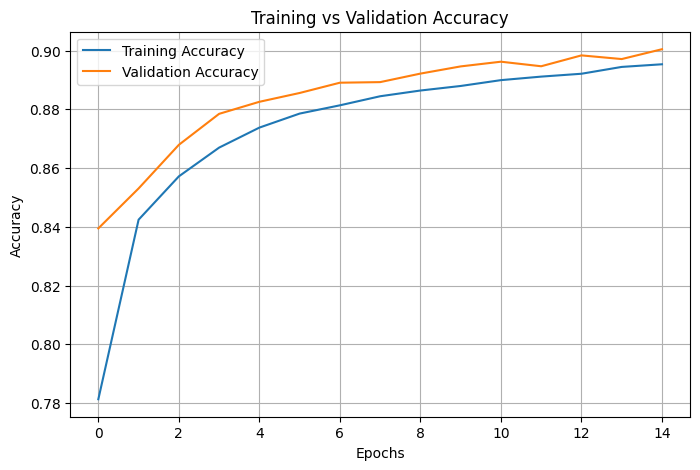

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()


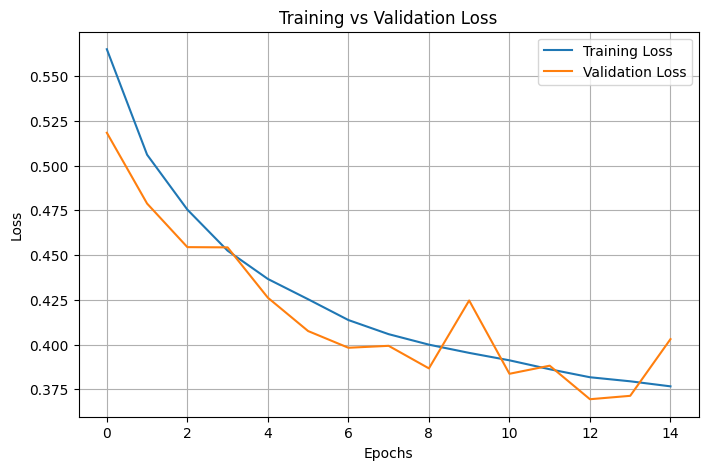

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()
